In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import ast

In [40]:
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
data_path = os.path.join(parent_path, 'data')

portfolio = pd.read_csv(data_path + '\\portfolio.csv').drop(columns = 'Unnamed: 0')
profile = pd.read_csv(data_path + '\\profile.csv').drop(columns = 'Unnamed: 0')
transcript = pd.read_csv(data_path + '\\transcript.csv').drop(columns = 'Unnamed: 0')

In [41]:
# 수령 가능한 프로모션 혜택에 대한 정보와, 각 혜택의 유형, 기간, 보상, 그리고 고객에게 어떻게 전달되었는지를 포함한 기본 정보
portfolio.head()

,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [42]:
# 각 개인의 나이, 급여, 성별을 포함한 차원(속성) 데이터. 각 레코드(행)는 한 명의 고유한 고객 정보
profile.head()

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [43]:
# 고객이 받은 프로모션 제안의 단계별 기록. 
# 프로모션 수령 단계는 '수령(receiving)', '조회(viewing)', '완료(completing)'로 구분.
# 또한 고객 가입 이후 발생한 모든 거래 내역도 확인 가능. 
# 모든 기록에는 스타벅스와 상호작용한 날짜와 거래 금액(가치) 정보가 포함
transcript.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


- 데이터 관계를 살펴 보았을 때, **transcript에 profile, portfolio가 merge 되는 형식**인 것 같음.
- transcript부터 전처리 시작

### 1. Transcript 전처리

In [44]:
transcript['event'].unique()

<StringArray>
['offer received', 'offer viewed', 'transaction', 'offer completed']
Length: 4, dtype: str

In [51]:
transcript[transcript['event'] == 'offer completed']['value'][12658]

"{'offer_id': '2906b810c7d4411798c6938adc9daaa5', 'reward': 2}"

In [12]:
# event가 offer인 경우 offer id만 기재
transcript[transcript['event'].str.contains('offer')].head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [13]:
# event가 transaction인 경우 amount로 키 값 기재
transcript[transcript['event'] == 'transaction'].head()

,person,event,value,time
12654,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0
12659,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0
12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0
12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0


In [14]:
# ast.literal_eval로 string -> dictionary로 변경
transcript['value_dict'] = transcript['value'].apply(ast.literal_eval)
transcript['value_dict']

0         {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
1         {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
2         {'offer id': '2906b810c7d4411798c6938adc9daaa5'}
3         {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}
4         {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}
                                ...                       
306529                      {'amount': 1.5899999999999999}
306530                                    {'amount': 9.53}
306531                                    {'amount': 3.61}
306532                      {'amount': 3.5300000000000002}
306533                                    {'amount': 4.05}
Name: value_dict, Length: 306534, dtype: object

In [15]:
# offer id가 offer id, offer_id 두 개로 기재. 키로 가져올 때 주의해야 함
tmp = transcript['value_dict'].map(lambda x: x.keys())
tmp2 = [list(x)[0] for x in tmp]
set(tmp2)

{'amount', 'offer id', 'offer_id'}

In [16]:
# offer_id, offer id로 분리
transcript['offer_id'] = transcript['value_dict'].apply(lambda x: x.get('offer id') or x.get('offer_id'))
transcript['transaction_amount'] = transcript['value_dict'].apply(lambda x: x.get('amount'))

In [17]:
# 프로모션 이벤트에 대한 id 추출 잘 된 것 확인
transcript.head()

,person,event,value,time,value_dict,offer_id,transaction_amount
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},2906b810c7d4411798c6938adc9daaa5,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


In [18]:
# transaction에 대한 amount 추출 잘 된 것 확인
transcript.tail()

,person,event,value,time,value_dict,offer_id,transaction_amount
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714,{'amount': 1.5899999999999999},NaN,1.59
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714,{'amount': 9.53},NaN,9.53
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714,{'amount': 3.61},NaN,3.61
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714,{'amount': 3.5300000000000002},NaN,3.53
306533,c02b10e8752c4d8e9b73f918558531f7,transaction,{'amount': 4.05},714,{'amount': 4.05},NaN,4.05


In [19]:
transcript = transcript.drop(columns = ['value','value_dict'])

In [20]:
transcript.head()

,person,event,time,offer_id,transaction_amount
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


<Axes: xlabel='time', ylabel='Count'>

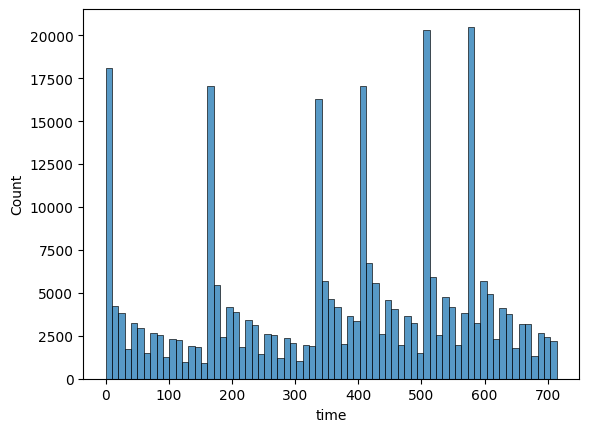

In [21]:
# 아마 프로모션 이후의 시간으로 추측. 24로 나눠서 일 별 반응 보는 것도 가능해보임.
# 추가적으로 특정 값에 모여있는데, 이게 뭔지는 더 봐야 알 듯.
sns.histplot(transcript['time'])

In [22]:
# 상위 6개의 데이터 408, 576 등 특정 정수 존재
transcript['time'].value_counts(ascending = False).head(10)

time
408    17030
576    17015
504    16822
336    16302
168    16150
0      15561
414     3583
510     3514
582     3484
588     3222
Name: count, dtype: int64

정확히 일자 별로 나누어지므로, 대략 전체 데이터의 32%가 일자로 표기되어있음.

-> 일자로 볼지, 아니면 시간 정보로도 같이 볼지 생각해봐야 할 듯.

In [23]:
time_top6 = [408,576,504,336,168,0]

[time / 24 for time in time_top6]

[17.0, 24.0, 21.0, 14.0, 7.0, 0.0]

### 2. profile 전처리

시각화 했을 때, age가 118세인 데이터가 다수 존재

<Axes: xlabel='age', ylabel='Count'>

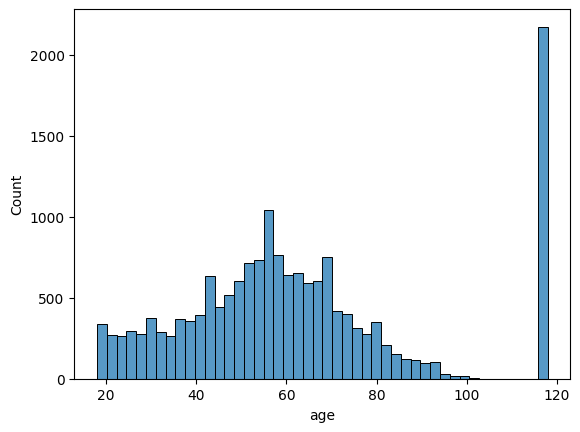

In [24]:
sns.histplot(profile['age'])

In [25]:
# profile의 2175개의 missing과 gender, incomde의 missing이 동일.
print(len(profile[profile['age'] == 118]))
profile.isna().sum()

2175


gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

아마 가입 시 **정보 미기재** 한 사람들에 대해서, **나이 118 + income, gender missing 기재** 한 것으로 추측

In [26]:
# 정보 미기입자 2175명, 기입자 14825명
profile['has_profile'] = [0 if num == 118 else 1 for num in profile['age']]
profile['has_profile'].value_counts()

has_profile
1    14825
0     2175
Name: count, dtype: int64

In [27]:
# became_member_on은 날짜 변수로 변환해둠
date_string = profile['became_member_on'].astype('str')
profile['became_member_on'] = pd.to_datetime(date_string.map(lambda x: x[:4] + '-' + x[4:6] + '-' + x[6:]))
profile.head()

,gender,age,id,became_member_on,income,has_profile
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN,0
1,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,1
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN,0
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,1
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN,0


### 3. portfolio 전처리

In [28]:
# 4개의 채널이 존재. 단일 채널만으로 프로모션은 하지 않는 것 같음.
portfolio['channels'].unique()

<StringArray>
[       '['email', 'mobile', 'social']',
 '['web', 'email', 'mobile', 'social']',
           '['web', 'email', 'mobile']',
                     '['web', 'email']']
Length: 4, dtype: str

간단하게 원-핫 인코딩 진행.
-> 이거 추후에 아니다 싶으면 롤백하겠습니다.

In [29]:
portfolio['email'] = portfolio['channels'].str.contains('email').astype(int)
portfolio['web'] = portfolio['channels'].str.contains('web').astype(int)
portfolio['mobile'] = portfolio['channels'].str.contains('mobile').astype(int)
portfolio['social'] = portfolio['channels'].str.contains('social').astype(int)

In [30]:
portfolio = portfolio.drop(columns = 'channels')
portfolio.head()

,reward,difficulty,duration,offer_type,id,email,web,mobile,social
0,10,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,1,0,1,1
1,10,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,1,0
3,5,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,1,0
4,5,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,1,0,0


### 4. Merge

In [31]:
total_df = pd.merge(transcript, profile, left_on='person', right_on='id', how='left')
total_df = pd.merge(total_df, portfolio, left_on='offer_id', right_on='id', how='left')

# 고객 id, offer id 중복 제거
total_df = total_df.drop(columns = ['id_x','id_y'])

In [32]:
print('전체 데이터 개수 : ', len(total_df))
total_df.head()

전체 데이터 개수 :  306534


,person,event,time,offer_id,transaction_amount,gender,age,became_member_on,income,has_profile,reward,difficulty,duration,offer_type,email,web,mobile,social
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75,2017-05-09,100000.0,1,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,118,2017-08-04,NaN,0,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,M,68,2018-04-26,70000.0,1,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,118,2017-09-25,NaN,0,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,118,2017-10-02,NaN,0,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0


In [52]:
for event in ['offer received', 'offer viewed', 'offer completed', 'transaction']:
    print(f'각 {event}의 unique offer type')
    print(total_df.loc[total_df['event'] == event, 'offer_type'].unique())

각 offer received의 unique offer type
<StringArray>
['bogo', 'discount', 'informational']
Length: 3, dtype: str
각 offer viewed의 unique offer type
<StringArray>
['bogo', 'informational', 'discount']
Length: 3, dtype: str
각 offer completed의 unique offer type
<StringArray>
['discount', 'bogo']
Length: 2, dtype: str
각 transaction의 unique offer type
<StringArray>
[nan]
Length: 1, dtype: str


- 규열님이 Prep으로 처리해주셔서, 이건 따로 사용 안 해도 괜찮을 것 같음.